In [2]:
# ==========================================
# POINT 1: LOAD THE DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display basic information
print("\nDataset information:")
df.info()

Saving diabetes.csv to diabetes (2).csv
First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset shape: (768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [3]:
# ==========================================
# POINT 2: SELECT TARGET AND PREDICTORS
# ==========================================

# Continuous target variable
target = "Glucose"

# Predictor variables
features = [
    "Pregnancies",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# Create X and y
X = df[features]
y = df[target]

print("Target variable:", target)
print("\nPredictor variables:")
print(features)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display descriptive statistics
print("\nTarget variable statistics:")
display(y.describe())

print("\nPredictor statistics:")
display(X.describe())

Target variable: Glucose

Predictor variables:
['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Shape of X: (768, 7)
Shape of y: (768,)

Target variable statistics:


,Glucose
count,768.000000
mean,121.677083
std,30.464161
min,44.000000
25%,99.750000
50%,117.000000
75%,140.250000
max,199.000000



Predictor statistics:


,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885
std,3.369578,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232
min,0.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000
50%,3.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000
75%,6.000000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000
max,17.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [4]:
# ==========================================
# POINT 3: CHECK AND PREPROCESS MISSING VALUES
# ==========================================

# Make a copy so original dataset remains unchanged
data = df.copy()

# Variables where zero is considered invalid
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zeros before preprocessing
print("Number of zero values before preprocessing:\n")

for col in invalid_zero_columns:
    print(col, ":", (data[col] == 0).sum())

# Replace invalid zero values with NaN
data[invalid_zero_columns] = data[invalid_zero_columns].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros:")
print(data.isnull().sum())

# Fill missing values using median
for col in invalid_zero_columns:
    data[col] = data[col].fillna(data[col].median())

print("\nMissing values after median imputation:")
print(data.isnull().sum())

# Check the cleaned data
print("\nCleaned dataset:")
display(data.head())

Number of zero values before preprocessing:

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0

Missing values after replacing invalid zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Cleaned dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [5]:
# ==========================================
# POINT 4: TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Define X and y using cleaned data
X = data[features]
y = data[target]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (614, 7)
y_train: (614,)

Testing set:
X_test: (154, 7)
y_test: (154,)


In [6]:
# ==========================================
# POINT 5: DEVELOP REGRESSION MODEL
# ==========================================

from sklearn.linear_model import LinearRegression

# Create Linear Regression model
model = LinearRegression()

print("Multiple Linear Regression model created successfully.")

print("\nModel type:")
print(model)

Multiple Linear Regression model created successfully.

Model type:
LinearRegression()


In [7]:
# ==========================================
# POINT 6: TRAIN THE MODEL
# ==========================================

# Train the regression model
model.fit(X_train, y_train)

print("Model training completed successfully.")

# Display coefficients
print("\nRegression coefficients:")

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

display(coefficients)

print("\nIntercept:", model.intercept_)

Model training completed successfully.

Regression coefficients:


,Feature,Coefficient
0,Pregnancies,0.020947
1,BloodPressure,0.226425
2,SkinThickness,-0.054091
3,Insulin,0.139321
4,BMI,0.441457
5,DiabetesPedigreeFunction,6.008047
6,Age,0.504329



Intercept: 53.503065187063385


In [8]:
# ==========================================
# POINT 7: GENERATE PREDICTIONS
# ==========================================

# Predict glucose values for test data
y_pred = model.predict(X_test)

# Create comparison dataframe
comparison = pd.DataFrame({
    "Actual Glucose": y_test.values,
    "Predicted Glucose": y_pred
})

# Calculate prediction error
comparison["Residual"] = (
    comparison["Actual Glucose"] -
    comparison["Predicted Glucose"]
)

print("Actual vs Predicted Glucose:")
display(comparison.head(20))

Actual vs Predicted Glucose:


,Actual Glucose,Predicted Glucose,Residual
0,98,130.726560,-32.726560
1,112,110.316438,1.683562
2,108,105.993164,2.006836
3,107,117.754504,-10.754504
4,136,126.525595,9.474405
5,103,140.999084,-37.999084
6,71,96.048734,-25.048734
7,117,124.883990,-7.883990
8,154,120.383767,33.616233
9,147,133.057145,13.942855


In [9]:
# ==========================================
# POINT 8: MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Display results
print("Regression Model Performance")
print("=" * 40)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-squared (R²):", round(r2, 3))

Regression Model Performance
Mean Absolute Error (MAE): 21.3
Mean Squared Error (MSE): 685.99
Root Mean Squared Error (RMSE): 26.19
R-squared (R²): 0.318


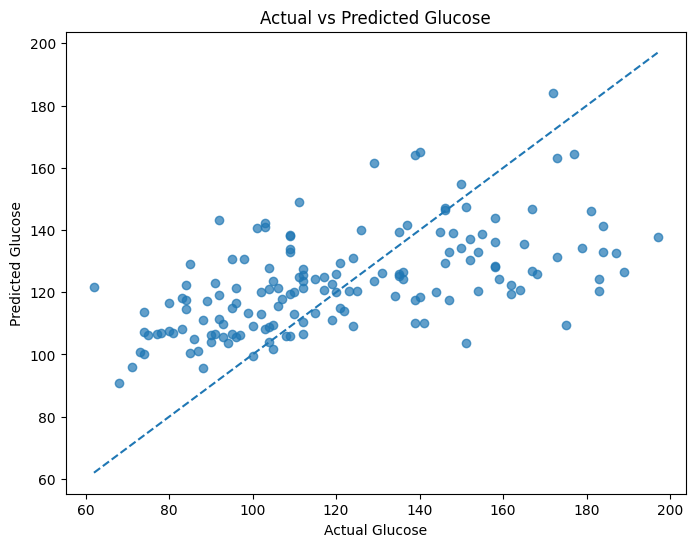

In [10]:
# ==========================================
# POINT 9A: ACTUAL VS PREDICTED VALUES
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Glucose")
plt.ylabel("Predicted Glucose")
plt.title("Actual vs Predicted Glucose")

plt.show()

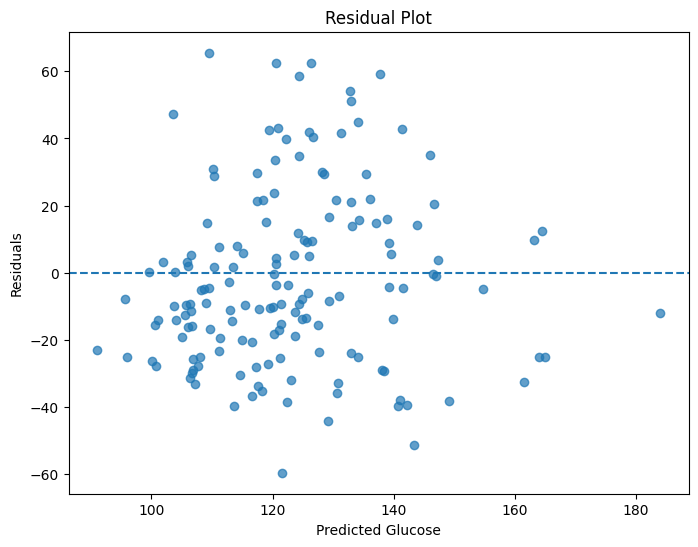

In [11]:
# ==========================================
# POINT 9B: RESIDUAL ANALYSIS
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

# Zero residual line
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Glucose")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

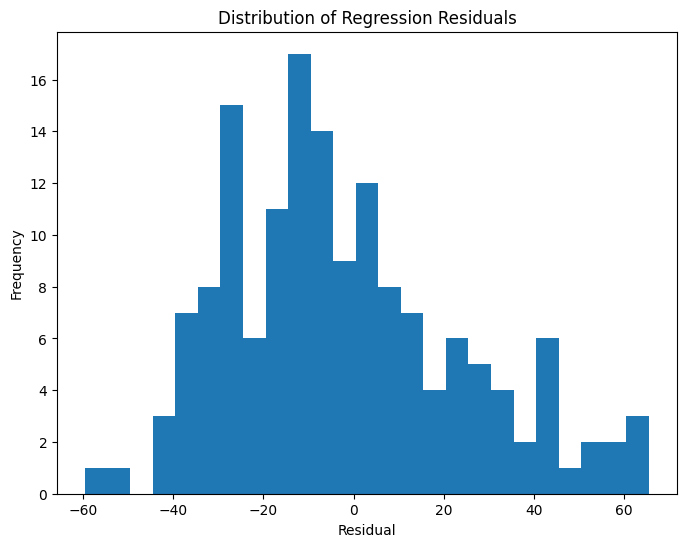

In [12]:
# ==========================================
# POINT 9C: RESIDUAL DISTRIBUTION
# ==========================================

plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=25)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")

plt.show()

In [13]:
# ==========================================
# POINT 9D: ACTUAL VS PREDICTED TABLE
# ==========================================

results = pd.DataFrame({
    "Actual Glucose": y_test.values,
    "Predicted Glucose": y_pred,
    "Residual": residuals.values
})

display(results.head(20))

,Actual Glucose,Predicted Glucose,Residual
0,98,130.726560,-32.726560
1,112,110.316438,1.683562
2,108,105.993164,2.006836
3,107,117.754504,-10.754504
4,136,126.525595,9.474405
5,103,140.999084,-37.999084
6,71,96.048734,-25.048734
7,117,124.883990,-7.883990
8,154,120.383767,33.616233
9,147,133.057145,13.942855


In [14]:
# ==========================================
# POINT 10: INTERPRET MODEL RESULTS
# ==========================================

# Create coefficient table
interpretation = pd.DataFrame({
    "Predictor": features,
    "Coefficient": model.coef_
})

# Absolute coefficient
interpretation["Absolute Effect"] = interpretation["Coefficient"].abs()

# Sort by importance
interpretation = interpretation.sort_values(
    by="Absolute Effect",
    ascending=False
)

print("Predictor influence based on regression coefficients:")
display(interpretation)

print("\nModel Interpretation")
print("=" * 50)

print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

print("\nInterpretation:")
print(
    f"The model explains approximately {r2 * 100:.1f}% "
    "of the variation in Glucose based on the selected predictors."
)

print(
    f"On average, the model's predictions differ from the actual "
    f"glucose values by approximately {mae:.2f} units (MAE)."
)

print(
    f"The RMSE of {rmse:.2f} indicates the typical magnitude of "
    "prediction error while giving greater weight to larger errors."
)

Predictor influence based on regression coefficients:


,Predictor,Coefficient,Absolute Effect
5,DiabetesPedigreeFunction,6.008047,6.008047
6,Age,0.504329,0.504329
4,BMI,0.441457,0.441457
1,BloodPressure,0.226425,0.226425
3,Insulin,0.139321,0.139321
2,SkinThickness,-0.054091,0.054091
0,Pregnancies,0.020947,0.020947



Model Interpretation
R-squared: 0.318
RMSE: 26.19
MAE: 21.30

Interpretation:
The model explains approximately 31.8% of the variation in Glucose based on the selected predictors.
On average, the model's predictions differ from the actual glucose values by approximately 21.30 units (MAE).
The RMSE of 26.19 indicates the typical magnitude of prediction error while giving greater weight to larger errors.
